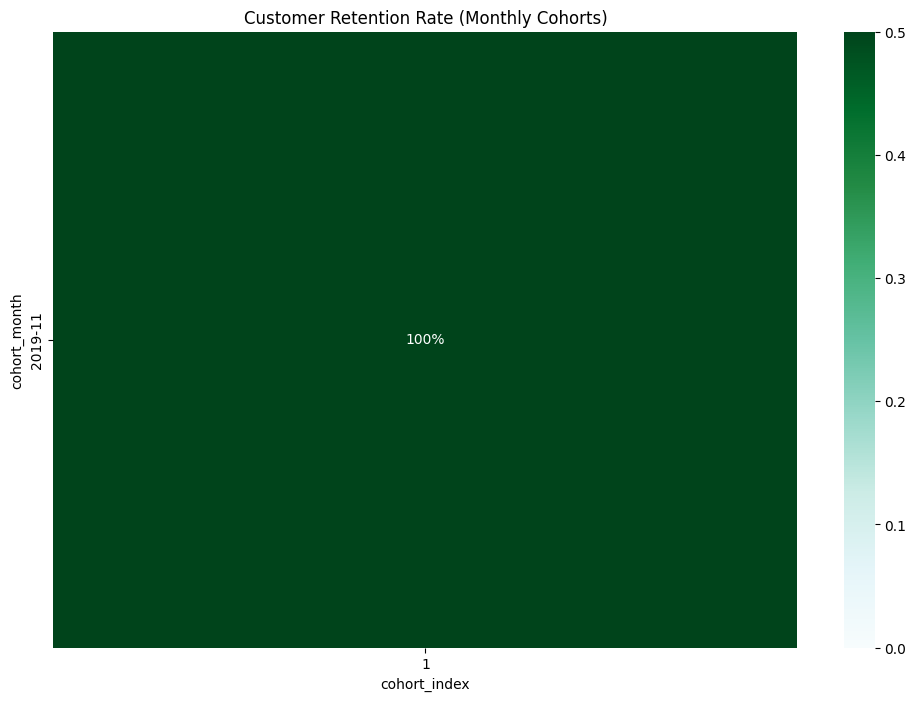

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
file_path = '2019-Nov.csv' 
cols_to_use = ['event_time', 'event_type', 'user_id', 'price']
df = pd.read_csv(file_path, usecols=cols_to_use, nrows=100000)
df = df[df['event_type'] == 'purchase']
df['event_time'] = pd.to_datetime(df['event_time']).dt.tz_localize(None)
df['order_month'] = df['event_time'].dt.to_period('M')
df['cohort_month'] = df.groupby('user_id')['event_time'].transform('min').dt.to_period('M')
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

order_year, order_month = get_date_int(df, 'order_month')
cohort_year, cohort_month = get_date_int(df, 'cohort_month')

years_diff = order_year - cohort_year
months_diff = order_month - cohort_month
df['cohort_index'] = years_diff * 12 + months_diff + 1
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['user_id'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='user_id')
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
plt.figure(figsize=(12, 8))
plt.title('Customer Retention Rate (Monthly Cohorts)')
sns.heatmap(data=retention, annot=True, fmt='.0%', vmin=0.0, vmax=0.5, cmap='BuGn')
plt.show()